In [27]:
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import re
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")


✅ All libraries imported successfully!
Pandas version: 3.0.3


In [28]:
print("📊 Loading data...")
df = pd.read_csv("../data/nycparking2025.csv")
print(f"✅ Loaded {len(df):,} rows and {len(df.columns)} columns")

print("\n📋 Column names:")
for i, col in enumerate(df.columns):
    print(f"   {i+1}. {col}")

print("\n👀 First 5 rows preview:")
df.head()

📊 Loading data...
✅ Loaded 7,057,515 rows and 43 columns

📋 Column names:
   1. Summons Number
   2. Plate ID
   3. Registration State
   4. Plate Type
   5. Issue Date
   6. Violation Code
   7. Vehicle Body Type
   8. Vehicle Make
   9. Issuing Agency
   10. Street Code1
   11. Street Code2
   12. Street Code3
   13. Vehicle Expiration Date
   14. Violation Location
   15. Violation Precinct
   16. Issuer Precinct
   17. Issuer Code
   18. Issuer Command
   19. Issuer Squad
   20. Violation Time
   21. Time First Observed
   22. Violation County
   23. Violation In Front Of Or Opposite
   24. House Number
   25. Street Name
   26. Intersecting Street
   27. Date First Observed
   28. Law Section
   29. Sub Division
   30. Violation Legal Code
   31. Days Parking In Effect
   32. From Hours In Effect
   33. To Hours In Effect
   34. Vehicle Color
   35. Unregistered Vehicle?
   36. Vehicle Year
   37. Meter Number
   38. Feet From Curb
   39. Violation Post Code
   40. Violation Descr

,Summons Number,Plate ID,Registration State,Plate Type,Issue Date,Violation Code,Vehicle Body Type,Vehicle Make,Issuing Agency,Street Code1,...,Vehicle Color,Unregistered Vehicle?,Vehicle Year,Meter Number,Feet From Curb,Violation Post Code,Violation Description,No Standing or Stopping Violation,Hydrant Violation,Double Parking Violation
0,9139716661,LKS7820,NY,PAS,07/02/2024,38,SUBN,TOYOT,T,26790,...,WH,NaN,2024.0,100038,0.0,71.0,38-Failure to Dsplay Meter Rec,NaN,NaN,NaN
1,4903865265,Y23UMS,NJ,PAS,06/21/2024,36,VAN,ME/BE,V,0,...,NaN,NaN,2024.0,NaN,0.0,NaN,PHTO SCHOOL ZN SPEED VIOLATION,NaN,NaN,NaN
2,9140510268,N76NJN,NJ,PAS,07/08/2024,14,SUBN,HYUND,T,24890,...,WHITE,NaN,0.0,NaN,0.0,12.0,14-No Standing,NaN,NaN,NaN
3,9136561575,42UD91,NY,MCL,07/12/2024,71,MCY,HONDA,T,47030,...,BLACK,NaN,0.0,NaN,0.0,9.0,71A-Insp Sticker Expired (NYS),NaN,NaN,NaN
4,9139621832,76925NE,NY,COM,07/11/2024,14,VAN,ISUZU,T,51090,...,WH,NaN,2018.0,NaN,0.0,12.0,14-No Standing,NaN,NaN,NaN


In [29]:
# Make column names easier to work with
df.columns = [col.replace(' ', '_').lower() for col in df.columns]

# Create a clean copy
df_clean = df.copy()

# Convert date column
df_clean['issue_date'] = pd.to_datetime(df_clean['issue_date'], errors='coerce')

# Clean text columns (uppercase and strip whitespace)
text_columns = ['plate_id', 'registration_state', 'vehicle_color', 'vehicle_make', 
                'vehicle_body_type', 'violation_description', 'street_name']

for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.upper().str.strip()
        df_clean[col] = df_clean[col].replace(['NAN', 'NONE', ''], pd.NA)

# Remove rows without a summons number (primary key)
df_clean = df_clean.dropna(subset=['summons_number'])

print(f"✅ Cleaned data: {len(df_clean):,} rows")
print(f"📅 Date range: {df_clean['issue_date'].min()} to {df_clean['issue_date'].max()}")

✅ Cleaned data: 7,057,515 rows
📅 Date range: 2000-06-03 00:00:00 to 2045-09-04 00:00:00


In [30]:
 #Load your extracted fines CSV
df_fines_raw = pd.read_csv("fines_extracted_fixed.csv")

print("=" * 60)
print("INSPECTING EXTRACTED FINES DATA")
print("=" * 60)

print(f"\n📊 Shape: {df_fines_raw.shape}")
print(f"\n📋 Columns: {df_fines_raw.columns.tolist()}")
print(f"\n👀 First 10 rows:")
print(df_fines_raw.head(10))
print(f"\n🔍 Data types:")
print(df_fines_raw.dtypes)
print(f"\n📊 Missing values:")
print(df_fines_raw.isnull().sum())
print(df_fines_raw.head(20))

INSPECTING EXTRACTED FINES DATA

📊 Shape: (91, 3)

📋 Columns: ['Violation ', 'Violation Description', 'Fine Amount']

👀 First 10 rows:
   Violation            Violation Description Fine Amount
0           1   FAILURE TO DISPLAY BUS PERMIT       $515 
1           2  NO OPERATOR NAM/ADD/PH DISPLAY       $515 
2           3  UNAUTHORIZED PASSENGER PICK-UP       $515 
3           4  BUS PARKING IN LOWER MANHATTAN         $0 
4           5              BUS LANE VIOLATION        $50 
5           6   OVERNIGHT TRACTOR TRAILER PKG       $250 
6           7    FAILURE TO STOP AT RED LIGHT        $50 
7           8                          IDLING       $115 
8           9   OBSTRUCTING TRAFFIC/INTERSECT       $115 
9          10     NO STOPPING-DAY/TIME LIMITS       $115 

🔍 Data types:
Violation                int64
Violation Description      str
Fine Amount                str
dtype: object

📊 Missing values:
Violation                0
Violation Description    0
Fine Amount              0
dtype

In [31]:
print("=" * 60)
print("CLEANING COMPLETE FINES DATA")
print("=" * 60)

# Load the complete fines CSV
# Note: Your column name has a trailing space 'Violation '
df_fines = pd.read_csv("fines_extracted_fixed.csv")

# Fix column names (remove trailing spaces)
df_fines.columns = df_fines.columns.str.strip()

print(f"✅ Cleaned column names: {df_fines.columns.tolist()}")
print(f"📊 Total rows in fines file: {len(df_fines):,}")

# Clean the Fine Amount column (remove $ and convert to number)
df_fines['fine_amount_clean'] = df_fines['Fine Amount'].astype(str).str.replace('$', '').str.strip()
df_fines['fine_amount_clean'] = pd.to_numeric(df_fines['fine_amount_clean'], errors='coerce')

# Clean violation code column
df_fines['violation_code'] = df_fines['Violation'].astype(str).str.strip()

# Remove any rows with missing fine amounts
df_fines = df_fines.dropna(subset=['fine_amount_clean'])

print(f"\n✅ After cleaning: {len(df_fines):,} violation codes with fines")
print(f"\n📊 Fine amount statistics:")
print(df_fines['fine_amount_clean'].describe())
print(f"\n📊 Fine amount distribution:")
print(df_fines['fine_amount_clean'].value_counts().sort_index().head(20))

CLEANING COMPLETE FINES DATA
✅ Cleaned column names: ['Violation', 'Violation Description', 'Fine Amount']
📊 Total rows in fines file: 91

✅ After cleaning: 90 violation codes with fines

📊 Fine amount statistics:
count     90.000000
mean     109.888889
std      122.421674
min        0.000000
25%       50.000000
50%       80.000000
75%      115.000000
max      650.000000
Name: fine_amount_clean, dtype: float64

📊 Fine amount distribution:
fine_amount_clean
0.0       4
35.0      7
45.0     11
50.0      6
60.0      3
65.0     14
95.0     10
115.0    26
165.0     1
180.0     1
250.0     1
515.0     5
650.0     1
Name: count, dtype: int64


In [32]:
# print("=" * 60)
# print("CHECKING PARKING DATA VIOLATION CODES")
# print("=" * 60)

# # How many unique violation codes in your parking data
# parking_codes = df_clean['violation_code'].astype(str).str.strip().nunique()
# print(f"📊 Unique violation codes in parking data: {parking_codes:,}")

# # Show sample of parking violation codes
# print(f"\n📋 Sample of violation codes in parking data:")
# print(df_clean['violation_code'].astype(str).str.strip().value_counts().head(20))

In [33]:
print("🔍 SCANNING FOR COLUMNS WITH REAL DATA")
print("=" * 60)

# List of all columns in your dataset
all_columns = ['summons_number', 'plate_id', 'registration_state', 'plate_type', 'issue_date',
               'violation_code', 'vehicle_body_type', 'vehicle_make', 'issuing_agency',
               'street_code1', 'street_code2', 'street_code3', 'vehicle_expiration_date',
               'violation_location', 'violation_precinct', 'issuer_precinct', 'issuer_code',
               'issuer_command', 'issuer_squad', 'violation_time', 'time_first_observed',
               'violation_county', 'violation_in_front_of_or_opposite', 'house_number',
               'street_name', 'intersecting_street', 'date_first_observed', 'law_section',
               'sub_division', 'violation_legal_code', 'days_parking_in_effect',
               'from_hours_in_effect', 'to_hours_in_effect', 'vehicle_color',
               'unregistered_vehicle?', 'vehicle_year', 'meter_number', 'feet_from_curb',
               'violation_post_code', 'violation_description', 'no_standing_or_stopping_violation',
               'hydrant_violation', 'double_parking_violation']

useful_columns = []

print("\n📊 COLUMNS WITH MEANINGFUL DATA:")
print("-" * 40)

for col in all_columns:
    if col in df_clean.columns:
        non_null_count = df_clean[col].notna().sum()
        non_null_pct = (non_null_count / len(df_clean)) * 100
        unique_count = df_clean[col].nunique()
        
        # Determine if column has useful data (more than 1% non-null)
        if non_null_pct > 1:
            useful_columns.append(col)
            print(f"\n✅ {col}")
            print(f"   Non-null: {non_null_count:,} rows ({non_null_pct:.1f}%)")
            print(f"   Unique values: {unique_count:,}")
            
            # Show sample values for context
            sample_values = df_clean[col].dropna().head(3).tolist()
            print(f"   Sample: {sample_values}")
        else:
            print(f"\n❌ {col} - Too few values ({non_null_pct:.1f}% non-null)")

print("\n" + "=" * 60)
print(f"📈 SUMMARY: {len(useful_columns)} columns have meaningful data out of {len(all_columns)}")
print("=" * 60)

🔍 SCANNING FOR COLUMNS WITH REAL DATA

📊 COLUMNS WITH MEANINGFUL DATA:
----------------------------------------

✅ summons_number
   Non-null: 7,057,515 rows (100.0%)
   Unique values: 7,057,515
   Sample: [9139716661, 4903865265, 9140510268]

✅ plate_id
   Non-null: 7,057,375 rows (100.0%)
   Unique values: 2,489,163
   Sample: ['LKS7820', 'Y23UMS', 'N76NJN']

✅ registration_state
   Non-null: 7,057,515 rows (100.0%)
   Unique values: 68
   Sample: ['NY', 'NJ', 'NJ']

✅ plate_type
   Non-null: 7,057,515 rows (100.0%)
   Unique values: 81
   Sample: ['PAS', 'PAS', 'PAS']

✅ issue_date
   Non-null: 7,056,917 rows (100.0%)
   Unique values: 794
   Sample: [Timestamp('2024-07-02 00:00:00'), Timestamp('2024-06-21 00:00:00'), Timestamp('2024-07-08 00:00:00')]

✅ violation_code
   Non-null: 7,057,515 rows (100.0%)
   Unique values: 98
   Sample: [38, 36, 14]

✅ vehicle_body_type
   Non-null: 7,038,869 rows (99.7%)
   Unique values: 676
   Sample: ['SUBN', 'VAN', 'SUBN']

✅ vehicle_make
   No

In [67]:
# ============================================
# CLEAN INVALID FUTURE DATES
# Run this BEFORE any time-based analysis
# ============================================

print("📅 Cleaning invalid future dates...")

# Store original row count
original_count = len(df_clean)

# Ensure issue_date is datetime type
df_clean['issue_date'] = pd.to_datetime(df_clean['issue_date'], errors='coerce')

# Get today's date
today = pd.Timestamp.now().normalize()

# Remove future dates (anything after today)
df_clean = df_clean[df_clean['issue_date'] <= today]

# Also remove dates that are unreasonably old (before 2000)
# Parking violation data in NYC is reliable from 2000 onward
df_clean = df_clean[df_clean['issue_date'] >= '2000-01-01']

# Remove rows where date conversion failed (NaT)
df_clean = df_clean.dropna(subset=['issue_date'])

# Count removed rows
removed_count = original_count - len(df_clean)
removed_percent = (removed_count / original_count) * 100

print(f"✅ Removed {removed_count:,} rows with invalid dates ({removed_percent:.1f}% of data)")
print(f"✅ Remaining rows: {len(df_clean):,}")
print(f"📅 New date range: {df_clean['issue_date'].min().date()} to {df_clean['issue_date'].max().date()}")

# Double-check no future dates remain
future_check = df_clean[df_clean['issue_date'] > today]
if len(future_check) == 0:
    print("✅ Verification: No future dates remain in dataset")
else:
    print(f"⚠️ Warning: {len(future_check)} future dates still present")

📅 Cleaning invalid future dates...
✅ Removed 720 rows with invalid dates (0.0% of data)
✅ Remaining rows: 7,056,795
📅 New date range: 2000-06-03 to 2026-05-23
✅ Verification: No future dates remain in dataset


👮 Issuing Agency Breakdown:


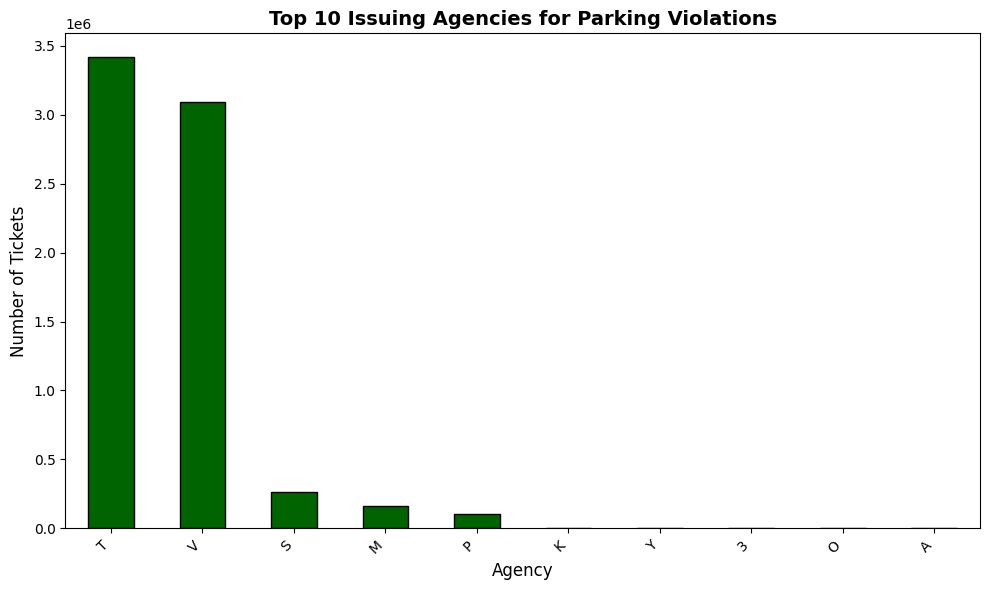

issuing_agency
T    3418953
V    3089906
S     265420
M     160687
P     104729
K       5008
Y       2538
3       2211
O       1291
A       1262
Name: count, dtype: int64


In [36]:
print("👮 Issuing Agency Breakdown:")

if 'issuing_agency' in df_clean.columns:
    agency_counts = df_clean['issuing_agency'].value_counts().head(10)
    
    plt.figure(figsize=(10, 6))
    agency_counts.plot(kind='bar', color='darkgreen', edgecolor='black')
    plt.xlabel('Agency', fontsize=12)
    plt.ylabel('Number of Tickets', fontsize=12)
    plt.title('Top 10 Issuing Agencies for Parking Violations', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(agency_counts)

🚓 Top 10 Precincts for Parking Violations:


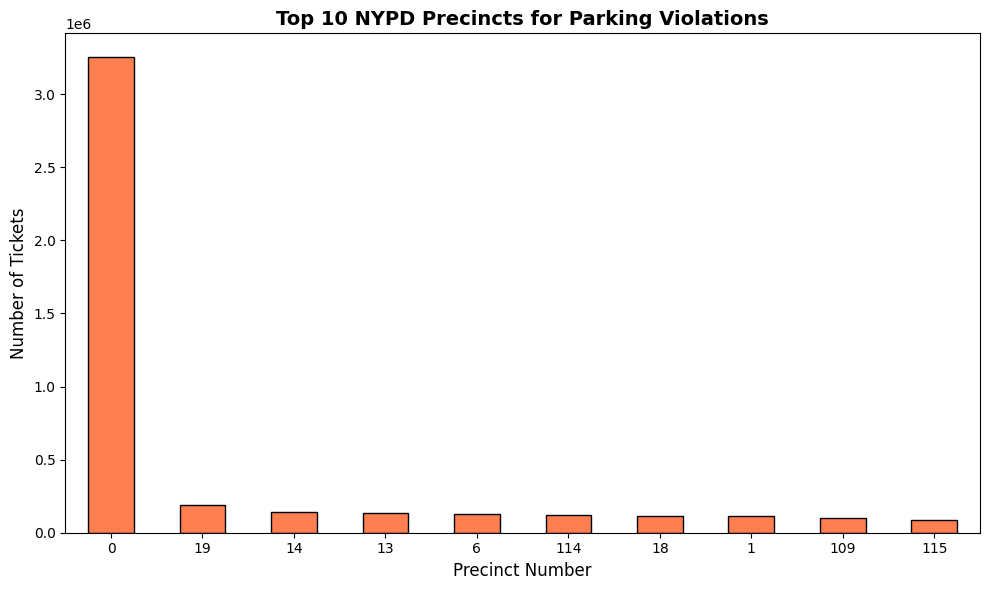

violation_precinct
0      3253725
19      191973
14      143673
13      135687
6       128885
114     119905
18      116346
1       114498
109      98194
115      86120
Name: count, dtype: int64


In [37]:
print("🚓 Top 10 Precincts for Parking Violations:")

top_precincts = df_clean['violation_precinct'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_precincts.plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Precinct Number', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.title('Top 10 NYPD Precincts for Parking Violations', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(top_precincts)

In [38]:
print("🔍 Checking for violation flag columns:")

# Look for columns that might indicate specific violation types
flag_columns = ['hydrant_violation', 'double_parking_violation', 'no_standing_or_stopping_violation']

for col in flag_columns:
    if col in df_clean.columns:
        values = df_clean[col].value_counts()
        non_null_count = df_clean[col].notna().sum()
        print(f"\n📋 {col}:")
        print(f"   Non-null values: {non_null_count:,} rows")
        if non_null_count > 0:
            print(f"   Value counts: {values.to_dict()}")
        else:
            print(f"   ℹ️ Column exists but all values are null")
    else:
        print(f"\n📋 {col}: Not found in dataset")

🔍 Checking for violation flag columns:

📋 hydrant_violation:
   Non-null values: 0 rows
   ℹ️ Column exists but all values are null

📋 double_parking_violation:
   Non-null values: 0 rows
   ℹ️ Column exists but all values are null

📋 no_standing_or_stopping_violation:
   Non-null values: 0 rows
   ℹ️ Column exists but all values are null


📍 Top Streets for Parking Violations:


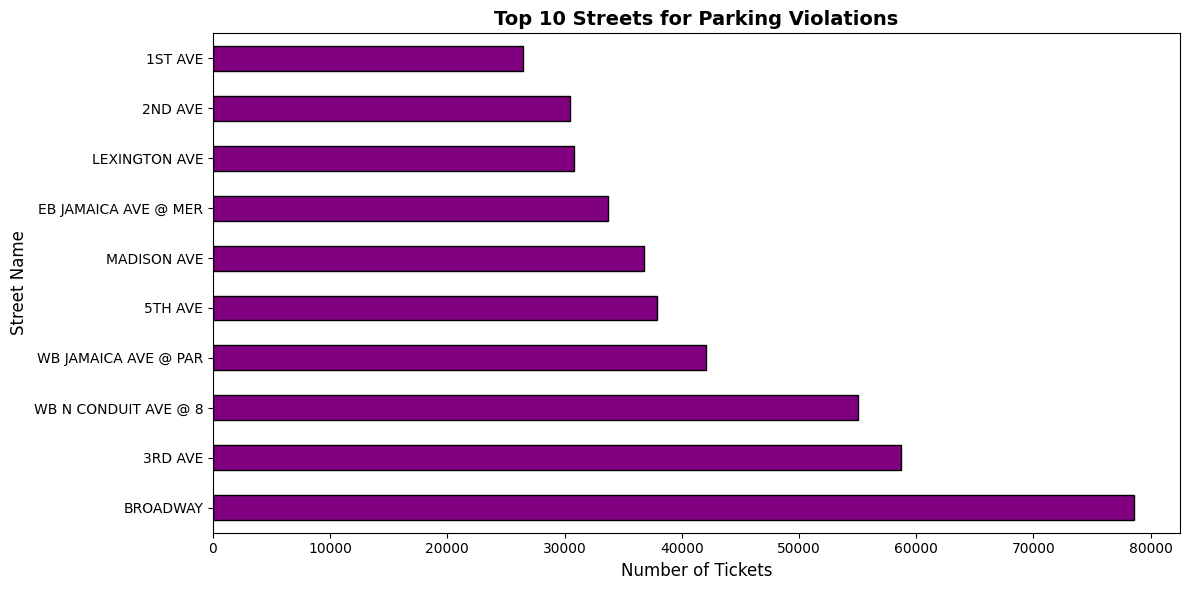

street_name
BROADWAY                78585
3RD AVE                 58727
WB N CONDUIT AVE @ 8    55031
WB JAMAICA AVE @ PAR    42085
5TH AVE                 37903
MADISON AVE             36759
EB JAMAICA AVE @ MER    33713
LEXINGTON AVE           30769
2ND AVE                 30432
1ST AVE                 26476
Name: count, dtype: int64


In [39]:
print("📍 Top Streets for Parking Violations:")

if 'street_name' in df_clean.columns:
    top_streets = df_clean['street_name'].value_counts().head(10)
    
    plt.figure(figsize=(12, 6))
    top_streets.plot(kind='barh', color='purple', edgecolor='black')
    plt.xlabel('Number of Tickets', fontsize=12)
    plt.ylabel('Street Name', fontsize=12)
    plt.title('Top 10 Streets for Parking Violations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(top_streets)

In [41]:
print("🔍 Missing Values Analysis:")
missing_counts = df_clean.isnull().sum()
missing_percent = (missing_counts / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent (%)': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.head(15))
else:
    print("✅ No missing values found!")

print(f"\n📊 Data Types:")
print(df_clean.dtypes.value_counts())

🔍 Missing Values Analysis:
                                   Missing Count  Missing Percent (%)
hydrant_violation                        7057515           100.000000
no_standing_or_stopping_violation        7057515           100.000000
double_parking_violation                 7057515           100.000000
unregistered_vehicle?                    6930572            98.201307
time_first_observed                      6629386            93.933715
meter_number                             6180579            87.574437
to_hours_in_effect                       4852748            68.760010
from_hours_in_effect                     4852738            68.759868
violation_post_code                      4589360            65.027988
violation_legal_code                     3808021            53.956966
issuer_squad                             3514933            49.804117
days_parking_in_effect                   3312914            46.941650
house_number                             3310972            46.

In [42]:
print("🚨 Top 10 Parking Violations:")

top_violations = df_clean.groupby(['violation_code', 'violation_description']).size().reset_index(name='ticket_count')
top_violations = top_violations.sort_values('ticket_count', ascending=False).head(10)
top_violations

🚨 Top 10 Parking Violations:


,violation_code,violation_description,ticket_count
54,36,PHTO SCHOOL ZN SPEED VIOLATION,2311451
36,21,21-NO PARKING (STREET CLEAN),555431
56,38,38-FAILURE TO DSPLAY METER REC,519815
6,5,BUS LANE VIOLATION,353584
20,14,14-NO STANDING,331544
9,7,FAILURE TO STOP AT RED LIGHT,318581
59,40,40-FIRE HYDRANT,238671
37,21,NO PARKING STREET CLEANING,236653
110,71,71A-INSP STICKER EXPIRED (NYS),191366
34,20,20A-NO PARKING (NON-COM),179482


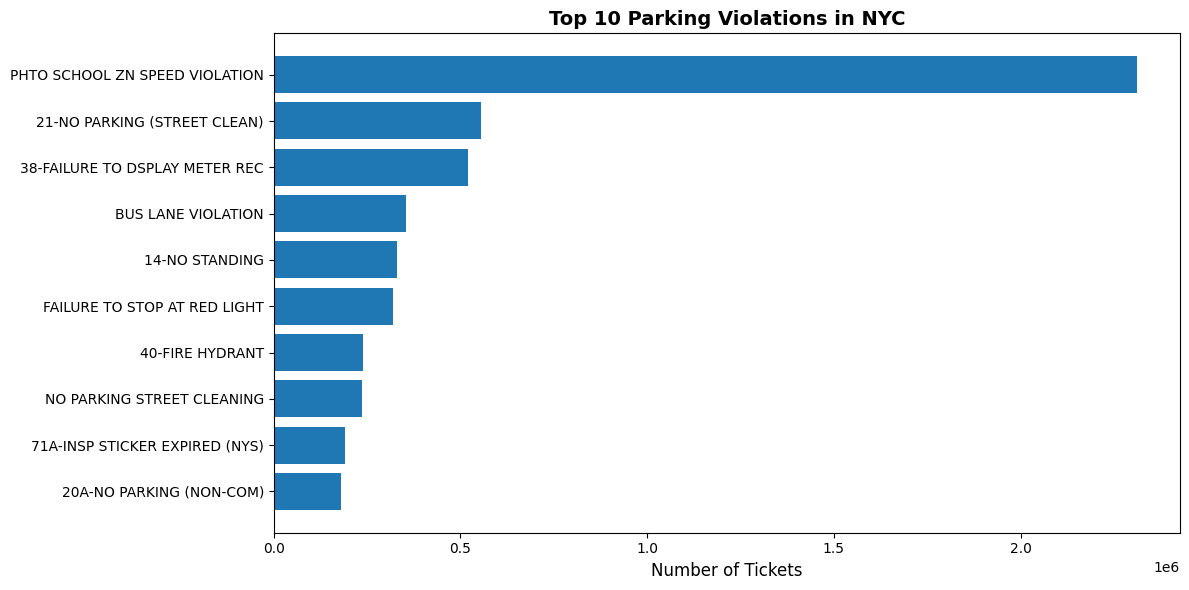

In [43]:
plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(top_violations)), top_violations['ticket_count'])
plt.yticks(range(len(top_violations)), top_violations['violation_description'].str[:50])
plt.xlabel('Number of Tickets', fontsize=12)
plt.title('Top 10 Parking Violations in NYC', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [44]:
print("🎨 Cleaning and Standardizing Vehicle Colors...")

# Create a color mapping dictionary
color_mapping = {
    # Black variations
    'BLK': 'BLACK',
    'BLACK': 'BLACK',
    'BK': 'BLACK',
    'BL': 'BLACK',
    
    # White variations
    'WHI': 'WHITE',
    'WHITE': 'WHITE',
    'WHT': 'WHITE',
    'WH': 'WHITE',
    
    # Gray/Grey variations
    'GY': 'GREY',
    'GREY': 'GREY',
    'GRAY': 'GREY',
    'GRY': 'GREY',
    'SLV': 'SILVER',
    'SILVER': 'SILVER',
    'SILVE': 'SILVER',
    'SLVR': 'SILVER',
    
    # Blue variations
    'BLU': 'BLUE',
    'BLUE': 'BLUE',
    'LTBLU': 'LIGHT BLUE',
    'DKBLU': 'DARK BLUE',
    
    # Red variations
    'RED': 'RED',
    'RD': 'RED',
    
    # Green variations
    'GRN': 'GREEN',
    'GREEN': 'GREEN',
    'GR': 'GREEN',
    
    # Brown variations
    'BRO': 'BROWN',
    'BR': 'BROWN',
    'BROWN': 'BROWN',
    'TAN': 'BROWN',
    'TN': 'BROWN',
    'BEIGE': 'BROWN',
    
    # Other common colors
    'GLD': 'GOLD',
    'GL': 'GOLD',
    'GOLD': 'GOLD',
    'ORG': 'ORANGE',
    'ORANGE': 'ORANGE',
    'PNK': 'PINK',
    'PINK': 'PINK',
    'PUR': 'PURPLE',
    'PURPLE': 'PURPLE',
    'YEL': 'YELLOW',
    'YW': 'YELLOW',
    'YELLOW': 'YELLOW',
    
    # Multi-color or special
    'MULTI': 'MULTI-COLOR',
    'MULTICOLOR': 'MULTI-COLOR',
}

# Apply the mapping to create a standardized color column
df_clean['vehicle_color_standard'] = df_clean['vehicle_color'].map(color_mapping)

# For colors not in the mapping, keep the original but clean it
df_clean['vehicle_color_standard'] = df_clean['vehicle_color_standard'].fillna(df_clean['vehicle_color'])

# Remove any remaining NaN or unknown values
df_clean['vehicle_color_standard'] = df_clean['vehicle_color_standard'].replace(['NAN', 'UNKNOWN', '', ' '], pd.NA)

# Show the results of cleaning
print("\n📊 Before Cleaning - Top 10 Colors:")
before_counts = df_clean['vehicle_color'].value_counts().head(10)
print(before_counts)

print("\n📊 After Cleaning & Grouping - Top 10 Colors:")
after_counts = df_clean['vehicle_color_standard'].value_counts().head(10)
print(after_counts)

print("\n✅ Color standardization complete!")

🎨 Cleaning and Standardizing Vehicle Colors...

📊 Before Cleaning - Top 10 Colors:
vehicle_color
GY       1341278
WH       1283528
BK       1169952
BL        434321
WHITE     423165
BLACK     272146
RD        253331
GREY      211058
BLUE       92255
GR         88040
Name: count, dtype: int64

📊 After Cleaning & Grouping - Top 10 Colors:
vehicle_color_standard
BLACK     1931339
WHITE     1746765
GREY      1609060
RED        331540
BROWN      180434
GREEN      107893
BLUE       105070
SILVER      87690
YELLOW      49494
GOLD        32226
Name: count, dtype: int64

✅ Color standardization complete!


🎨 Top Standardized Vehicle Colors Receiving Tickets:


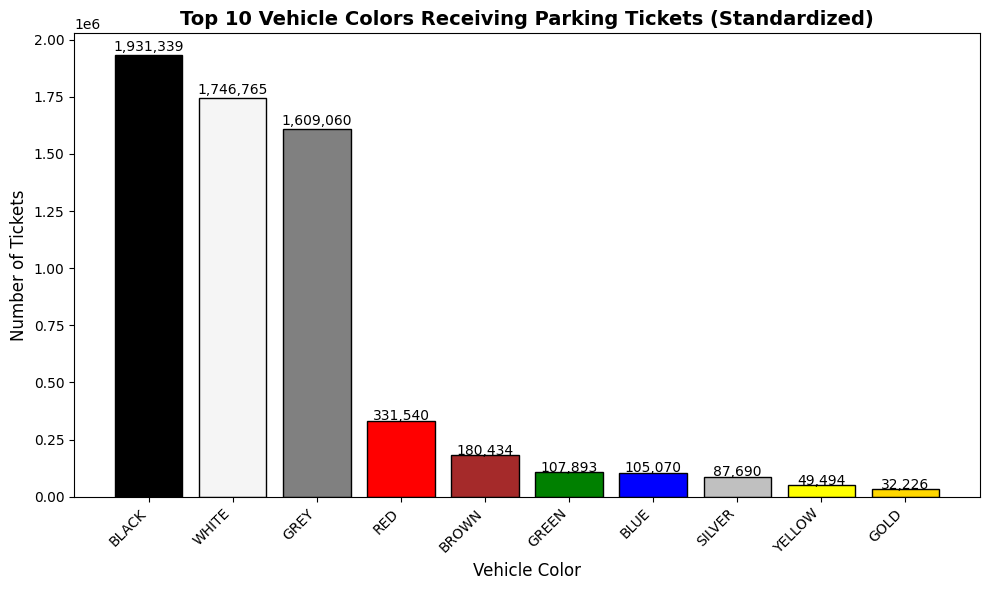


📊 Percentage Breakdown of Top Colors:
   BLACK: 1,931,339 tickets (30.4%)
   WHITE: 1,746,765 tickets (27.5%)
   GREY: 1,609,060 tickets (25.4%)
   RED: 331,540 tickets (5.2%)
   BROWN: 180,434 tickets (2.8%)
   GREEN: 107,893 tickets (1.7%)
   BLUE: 105,070 tickets (1.7%)
   SILVER: 87,690 tickets (1.4%)
   YELLOW: 49,494 tickets (0.8%)
   GOLD: 32,226 tickets (0.5%)


In [48]:
print("🎨 Top Standardized Vehicle Colors Receiving Tickets:")

# Filter out null/unknown values
valid_colors = df_clean[df_clean['vehicle_color_standard'].notna()]
valid_colors = valid_colors[valid_colors['vehicle_color_standard'] != 'UNKNOWN']

top_colors_standard = valid_colors['vehicle_color_standard'].value_counts().head(10)
top_colors_standard

# Create a dictionary that maps each color name to its bar color
bar_color_map = {
    'BLACK': 'black',
    'GREY': 'gray',
    'SILVER': 'silver',
    'WHITE': 'whitesmoke',
    'BLUE': 'blue',
    'RED': 'red',
    'GREEN': 'green',
    'BROWN': 'brown',
    'GOLD': 'gold',
    'ORANGE': 'orange',
    'YELLOW': 'yellow',
    'PURPLE': 'purple',
    'PINK': 'pink',
    'MULTI-COLOR': 'cyan'
}

# Get the actual color for each bar based on its name
bar_colors = [bar_color_map.get(color, 'skyblue') for color in top_colors_standard.index]

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(top_colors_standard)), top_colors_standard.values, color=bar_colors, edgecolor='black')
plt.xticks(range(len(top_colors_standard)), top_colors_standard.index, rotation=45, ha='right')
plt.xlabel('Vehicle Color', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.title('Top 10 Vehicle Colors Receiving Parking Tickets (Standardized)', fontsize=14, fontweight='bold')

# Add value labels on top of bars
for i, v in enumerate(top_colors_standard.values):
    plt.text(i, v + (v * 0.01), f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Show percentage breakdown
print("\n📊 Percentage Breakdown of Top Colors:")
total = len(valid_colors)
for color, count in top_colors_standard.items():
    pct = (count / total) * 100
    print(f"   {color}: {count:,} tickets ({pct:.1f}%)")

In [49]:
# Show examples of how specific colors were cleaned
print("🔍 Examples of Color Standardization:")
example_colors = ['GY', 'GREY', 'GRAY', 'GRY', 'BLK', 'BLACK', 'WHI', 'WHITE', 'SLV', 'SILVER']

for color in example_colors:
    standard = color_mapping.get(color, color)
    print(f"   '{color}' → '{standard}'")

# Show the most common original colors that became GREY
print("\n📋 Original colors that mapped to 'GREY':")
grey_originals = df_clean[df_clean['vehicle_color_standard'] == 'GREY']['vehicle_color'].value_counts().head(10)
print(grey_originals)

🔍 Examples of Color Standardization:
   'GY' → 'GREY'
   'GREY' → 'GREY'
   'GRAY' → 'GREY'
   'GRY' → 'GREY'
   'BLK' → 'BLACK'
   'BLACK' → 'BLACK'
   'WHI' → 'WHITE'
   'WHITE' → 'WHITE'
   'SLV' → 'SILVER'
   'SILVER' → 'SILVER'

📋 Original colors that mapped to 'GREY':
vehicle_color
GY      1341278
GREY     211058
GRY       40260
GRAY      16464
Name: count, dtype: int64


🎨 Top Standardized Vehicle Colors Receiving Tickets:


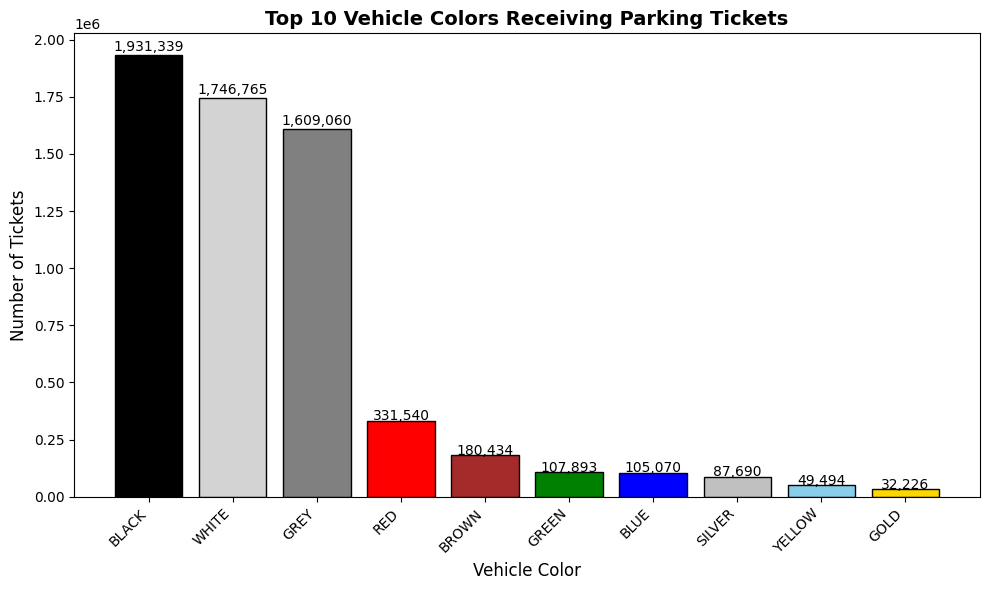


📊 Percentage Breakdown of Top Colors:
   BLACK: 1,931,339 tickets (30.4%)
   WHITE: 1,746,765 tickets (27.5%)
   GREY: 1,609,060 tickets (25.4%)
   RED: 331,540 tickets (5.2%)
   BROWN: 180,434 tickets (2.8%)
   GREEN: 107,893 tickets (1.7%)
   BLUE: 105,070 tickets (1.7%)
   SILVER: 87,690 tickets (1.4%)
   YELLOW: 49,494 tickets (0.8%)
   GOLD: 32,226 tickets (0.5%)


In [50]:
print("🎨 Top Standardized Vehicle Colors Receiving Tickets:")

# Filter out null/unknown values
valid_colors = df_clean[df_clean['vehicle_color_standard'].notna()]
valid_colors = valid_colors[valid_colors['vehicle_color_standard'] != 'UNKNOWN']

top_colors_standard = valid_colors['vehicle_color_standard'].value_counts().head(10)

# Create a color map for the bars
bar_colors = {
    'BLACK': 'black',
    'WHITE': 'lightgray',
    'GREY': 'gray',
    'SILVER': 'silver',
    'BLUE': 'blue',
    'RED': 'red',
    'GREEN': 'green',
    'BROWN': 'brown',
    'GOLD': 'gold',
    'ORANGE': 'orange'
}

# Get colors for the top 10
colors_to_use = [bar_colors.get(color, 'skyblue') for color in top_colors_standard.index]

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(top_colors_standard)), top_colors_standard.values, color=colors_to_use, edgecolor='black')
plt.xticks(range(len(top_colors_standard)), top_colors_standard.index, rotation=45, ha='right')
plt.xlabel('Vehicle Color', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.title('Top 10 Vehicle Colors Receiving Parking Tickets', fontsize=14, fontweight='bold')

# Add value labels on top of bars
for i, v in enumerate(top_colors_standard.values):
    plt.text(i, v + (v * 0.01), f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Show percentage breakdown
print("\n📊 Percentage Breakdown of Top Colors:")
total = len(valid_colors)
for color, count in top_colors_standard.items():
    pct = (count / total) * 100
    print(f"   {color}: {count:,} tickets ({pct:.1f}%)")

In [51]:
print("🚗 Top Vehicle Makes Receiving Tickets:")

valid_makes = df_clean[df_clean['vehicle_make'].notna()]
valid_makes = valid_makes[valid_makes['vehicle_make'] != 'UNKNOWN']
top_makes = valid_makes['vehicle_make'].value_counts().head(10)
top_makes

🚗 Top Vehicle Makes Receiving Tickets:


vehicle_make
TOYOT    835955
HONDA    818984
FORD     662531
NISSA    527206
CHEVR    372781
ME/BE    364481
BMW      347757
JEEP     322415
HYUND    245047
LEXUS    171774
Name: count, dtype: int64

🚗 Top Vehicle Body Types Receiving Tickets
(SUBN=Suburban, VAN=Van, 4DSD=4-Door Sedan, etc.)


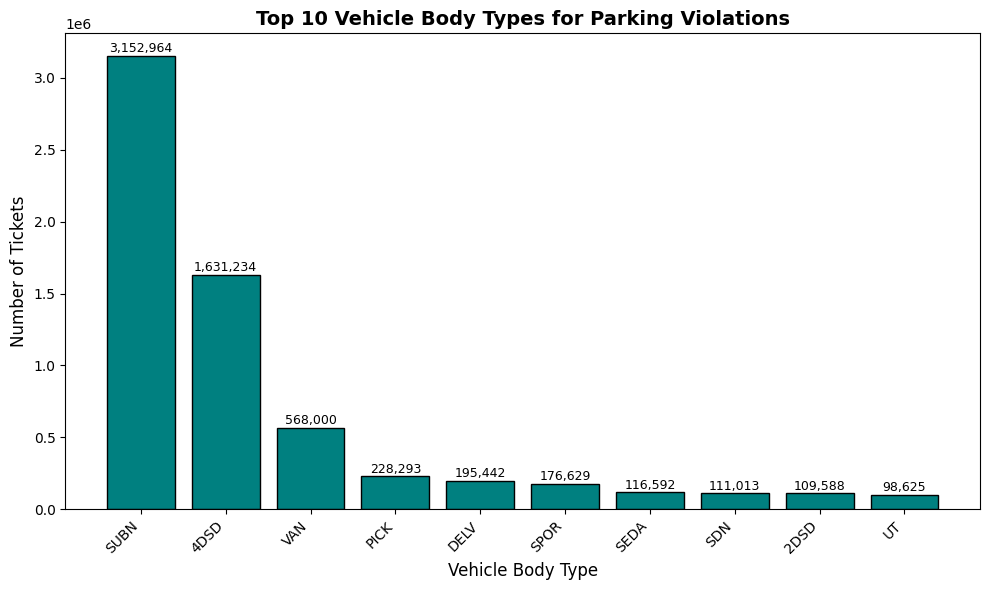


📊 Body Type Breakdown:
   SUBN: 3,152,964 tickets (44.7%)
   4DSD: 1,631,234 tickets (23.1%)
   VAN: 568,000 tickets (8.0%)
   PICK: 228,293 tickets (3.2%)
   DELV: 195,442 tickets (2.8%)
   SPOR: 176,629 tickets (2.5%)
   SEDA: 116,592 tickets (1.7%)
   SDN: 111,013 tickets (1.6%)
   2DSD: 109,588 tickets (1.6%)
   UT: 98,625 tickets (1.4%)


In [52]:
print("🚗 Top Vehicle Body Types Receiving Tickets")
print("(SUBN=Suburban, VAN=Van, 4DSD=4-Door Sedan, etc.)")

body_types = df_clean['vehicle_body_type'].value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(body_types)), body_types.values, color='teal', edgecolor='black')
plt.xlabel('Vehicle Body Type', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.title('Top 10 Vehicle Body Types for Parking Violations', fontsize=14, fontweight='bold')
plt.xticks(range(len(body_types)), body_types.index, rotation=45, ha='right')

for i, (bar, v) in enumerate(zip(bars, body_types.values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
             f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Body Type Breakdown:")
for body, count in body_types.items():
    pct = (count / len(df_clean)) * 100
    print(f"   {body}: {count:,} tickets ({pct:.1f}%)")

🗺️ Parking Violations by NYC Borough (Standardized)
⚠️ Unmapped county codes found: <StringArray>
[nan, 'Bronx', 'Rich', 'K   F', 'P', '108']
Length: 6, dtype: str


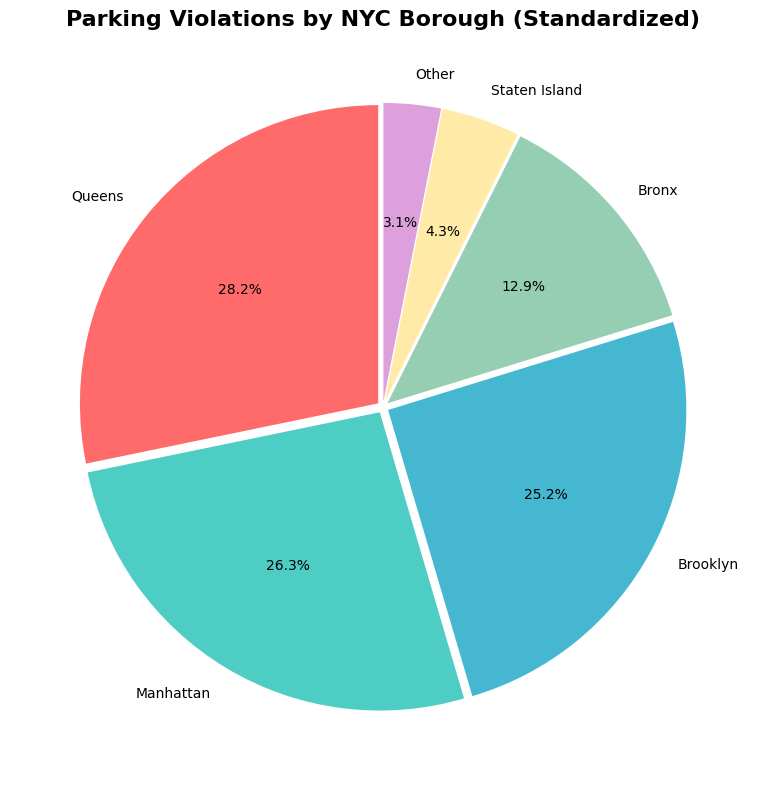


📊 Standardized Borough Breakdown:
   Queens: 1,992,635 tickets (28.2%)
   Manhattan: 1,857,859 tickets (26.3%)
   Brooklyn: 1,779,538 tickets (25.2%)
   Bronx: 908,226 tickets (12.9%)
   Staten Island: 300,196 tickets (4.3%)
   Other: 219,061 tickets (3.1%)


In [54]:
print("🗺️ Parking Violations by NYC Borough (Standardized)")

# Create a comprehensive mapping for boroughs
borough_mapping = {
    # Manhattan
    'NY': 'Manhattan',
    'MN': 'Manhattan',
    'MANHATTAN': 'Manhattan',
    'NEW YORK': 'Manhattan',
    
    # Brooklyn
    'BK': 'Brooklyn',
    'K': 'Brooklyn',
    'KINGS': 'Brooklyn',
    'BROOKLYN': 'Brooklyn',
    'Kings': 'Brooklyn',
    
    # Queens
    'QN': 'Queens',
    'Q': 'Queens',
    'QNS': 'Queens',
    'Queens': 'Queens',
    'Qns': 'Queens',
    
    # Bronx
    'BX': 'Bronx',
    'BRONX': 'Bronx',
    
    # Staten Island
    'SI': 'Staten Island',
    'R': 'Staten Island',
    'RICH': 'Staten Island',
    'ST': 'Staten Island',
}

# Apply the mapping
df_clean['borough'] = df_clean['violation_county'].map(borough_mapping)

# Fill any unmapped values with 'Other' and see what's left
unmapped = df_clean[df_clean['borough'].isna()]['violation_county'].unique()
if len(unmapped) > 0:
    print(f"⚠️ Unmapped county codes found: {unmapped}")
    df_clean['borough'] = df_clean['borough'].fillna('Other')

# Calculate borough totals
borough_counts = df_clean['borough'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
plt.pie(borough_counts.values, labels=borough_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=[0.02] * len(borough_counts))
plt.title('Parking Violations by NYC Borough (Standardized)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Standardized Borough Breakdown:")
for borough, count in borough_counts.items():
    pct = (count / len(df_clean)) * 100
    print(f"   {borough}: {count:,} tickets ({pct:.1f}%)")

In [55]:
# Show the mapping results
print("🔍 Verification of Borough Mapping:")
print("\nOriginal codes and their mapped boroughs:")
sample_codes = ['NY', 'MN', 'BK', 'K', 'KINGS', 'QN', 'Q', 'QNS', 'BX', 'BRONX', 'SI', 'R', 'RICH', 'ST']

for code in sample_codes:
    if code in df_clean['violation_county'].values:
        count = len(df_clean[df_clean['violation_county'] == code])
        mapped = borough_mapping.get(code, 'Other')
        print(f"   '{code}' → {mapped}: {count:,} tickets")

🔍 Verification of Borough Mapping:

Original codes and their mapped boroughs:
   'NY' → Manhattan: 1,538,405 tickets
   'MN' → Manhattan: 319,454 tickets
   'BK' → Brooklyn: 887,496 tickets
   'K' → Brooklyn: 771,332 tickets
   'QN' → Queens: 1,188,297 tickets
   'Q' → Queens: 756,579 tickets
   'QNS' → Queens: 4 tickets
   'BX' → Bronx: 908,223 tickets
   'BRONX' → Bronx: 3 tickets
   'R' → Staten Island: 55,155 tickets
   'ST' → Staten Island: 245,041 tickets


🎨 Top Standardized Vehicle Colors Receiving Tickets:


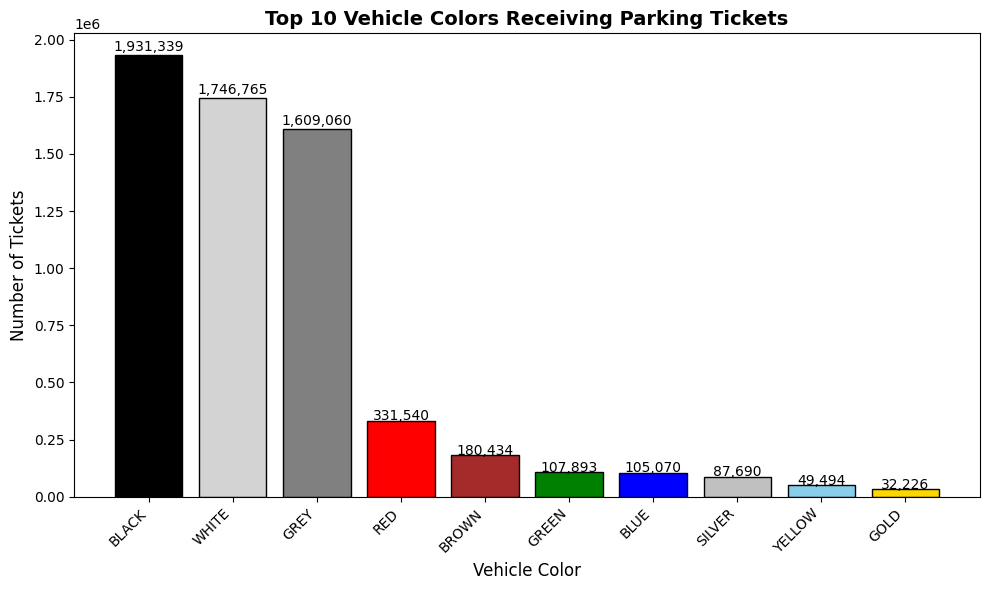


📊 Percentage Breakdown of Top Colors:
   BLACK: 1,931,339 tickets (30.4%)
   WHITE: 1,746,765 tickets (27.5%)
   GREY: 1,609,060 tickets (25.4%)
   RED: 331,540 tickets (5.2%)
   BROWN: 180,434 tickets (2.8%)
   GREEN: 107,893 tickets (1.7%)
   BLUE: 105,070 tickets (1.7%)
   SILVER: 87,690 tickets (1.4%)
   YELLOW: 49,494 tickets (0.8%)
   GOLD: 32,226 tickets (0.5%)


In [56]:
print("🎨 Top Standardized Vehicle Colors Receiving Tickets:")

# Filter out null/unknown values
valid_colors = df_clean[df_clean['vehicle_color_standard'].notna()]
valid_colors = valid_colors[valid_colors['vehicle_color_standard'] != 'UNKNOWN']

top_colors_standard = valid_colors['vehicle_color_standard'].value_counts().head(10)

# Create a color map for the bars
bar_colors = {
    'BLACK': 'black',
    'WHITE': 'lightgray',
    'GREY': 'gray',
    'SILVER': 'silver',
    'BLUE': 'blue',
    'RED': 'red',
    'GREEN': 'green',
    'BROWN': 'brown',
    'GOLD': 'gold',
    'ORANGE': 'orange'
}

# Get colors for the top 10
colors_to_use = [bar_colors.get(color, 'skyblue') for color in top_colors_standard.index]

# Create the visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(top_colors_standard)), top_colors_standard.values, color=colors_to_use, edgecolor='black')
plt.xticks(range(len(top_colors_standard)), top_colors_standard.index, rotation=45, ha='right')
plt.xlabel('Vehicle Color', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.title('Top 10 Vehicle Colors Receiving Parking Tickets', fontsize=14, fontweight='bold')

# Add value labels on top of bars
for i, v in enumerate(top_colors_standard.values):
    plt.text(i, v + (v * 0.01), f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Show percentage breakdown
print("\n📊 Percentage Breakdown of Top Colors:")
total = len(valid_colors)
for color, count in top_colors_standard.items():
    pct = (count / total) * 100
    print(f"   {color}: {count:,} tickets ({pct:.1f}%)")

📅 Vehicle Year Distribution:


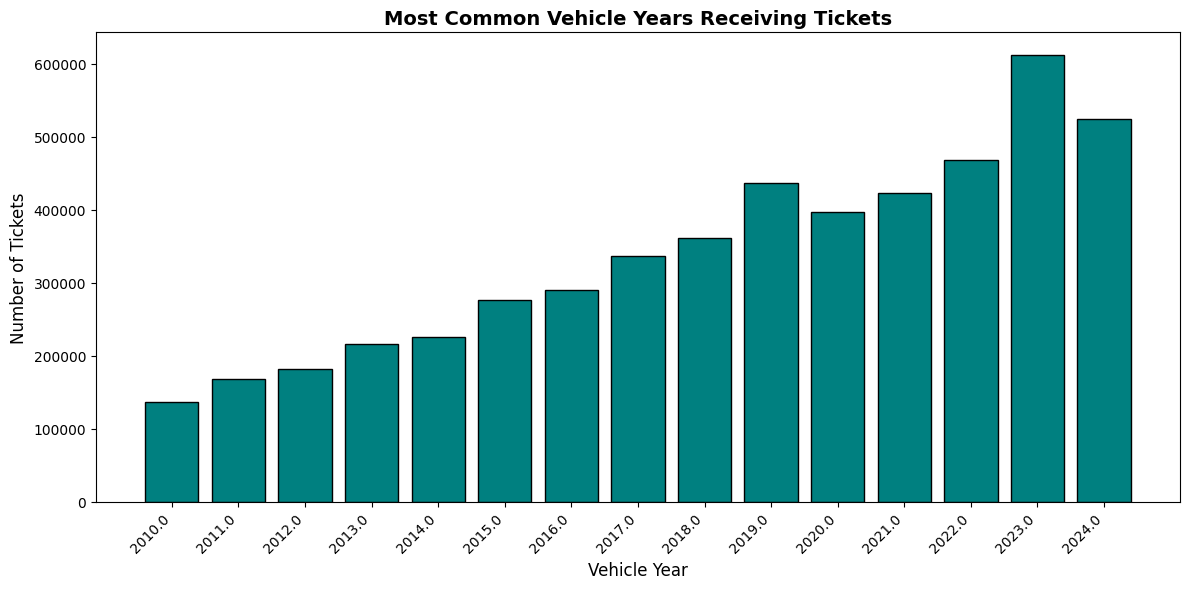

Most common vehicle year: 2023.0 (612,363 tickets)


In [57]:
print("📅 Vehicle Year Distribution:")

if 'vehicle_year' in df_clean.columns:
    # Filter reasonable years (1980 to current year)
    current_year = pd.Timestamp.now().year
    valid_years = df_clean[(df_clean['vehicle_year'] >= 1980) & (df_clean['vehicle_year'] <= current_year)]
    
    top_years = valid_years['vehicle_year'].value_counts().head(15).sort_index()
    
    plt.figure(figsize=(12, 6))
    plt.bar(top_years.index.astype(str), top_years.values, color='teal', edgecolor='black')
    plt.xlabel('Vehicle Year', fontsize=12)
    plt.ylabel('Number of Tickets', fontsize=12)
    plt.title('Most Common Vehicle Years Receiving Tickets', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(f"Most common vehicle year: {top_years.idxmax()} ({top_years.max():,} tickets)")

In [58]:
print("🚗 Top Violation by Vehicle Make:")

# Get top 5 vehicle makes
top_makes = df_clean['vehicle_make'].value_counts().head(5).index

# For each top make, find their most common violation
for make in top_makes:
    make_data = df_clean[df_clean['vehicle_make'] == make]
    top_violation = make_data['violation_description'].value_counts().head(1)
    if len(top_violation) > 0:
        print(f"   {make}: {top_violation.index[0][:50]} ({top_violation.values[0]:,} tickets)")

🚗 Top Violation by Vehicle Make:
   TOYOT: PHTO SCHOOL ZN SPEED VIOLATION (275,728 tickets)
   HONDA: PHTO SCHOOL ZN SPEED VIOLATION (275,663 tickets)
   FORD: PHTO SCHOOL ZN SPEED VIOLATION (156,092 tickets)
   NISSA: PHTO SCHOOL ZN SPEED VIOLATION (194,411 tickets)
   CHEVR: PHTO SCHOOL ZN SPEED VIOLATION (118,184 tickets)


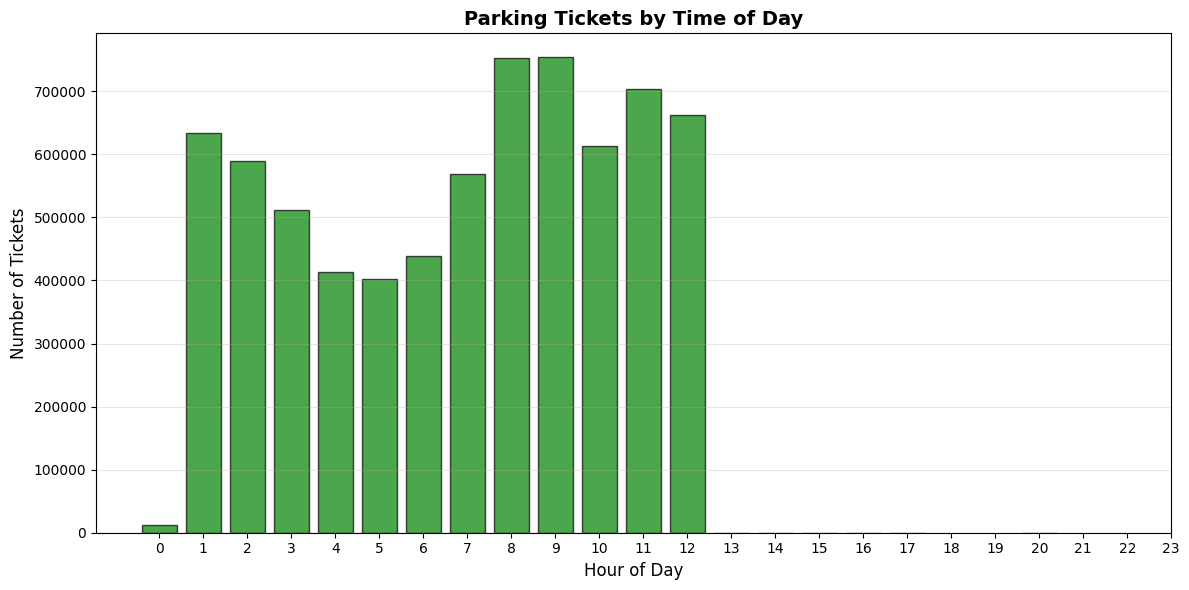


📊 Busiest Hours for Tickets:
hour
0.0     12683
1.0    633654
2.0    588587
3.0    512177
4.0    413937
Name: count, dtype: int64


In [59]:
if 'violation_time' in df_clean.columns:
    # Extract hour from violation time
    df_clean['hour'] = df_clean['violation_time'].astype(str).str[:2]
    df_clean['hour'] = pd.to_numeric(df_clean['hour'], errors='coerce')
    
    # Filter valid hours (0-23)
    hour_data = df_clean[df_clean['hour'].between(0, 23)]
    
    if len(hour_data) > 0:
        hour_counts = hour_data['hour'].value_counts().sort_index()
        
        plt.figure(figsize=(12, 6))
        plt.bar(hour_counts.index, hour_counts.values, color='green', edgecolor='black', alpha=0.7)
        plt.xlabel('Hour of Day', fontsize=12)
        plt.ylabel('Number of Tickets', fontsize=12)
        plt.title('Parking Tickets by Time of Day', fontsize=14, fontweight='bold')
        plt.xticks(range(0, 24))
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\n📊 Busiest Hours for Tickets:")
        print(hour_counts.head(5))
    else:
        print("⚠️ No valid hour data found")
else:
    print("⚠️ 'violation_time' column not found in dataset")

⏰ Time of Day Heatmap:


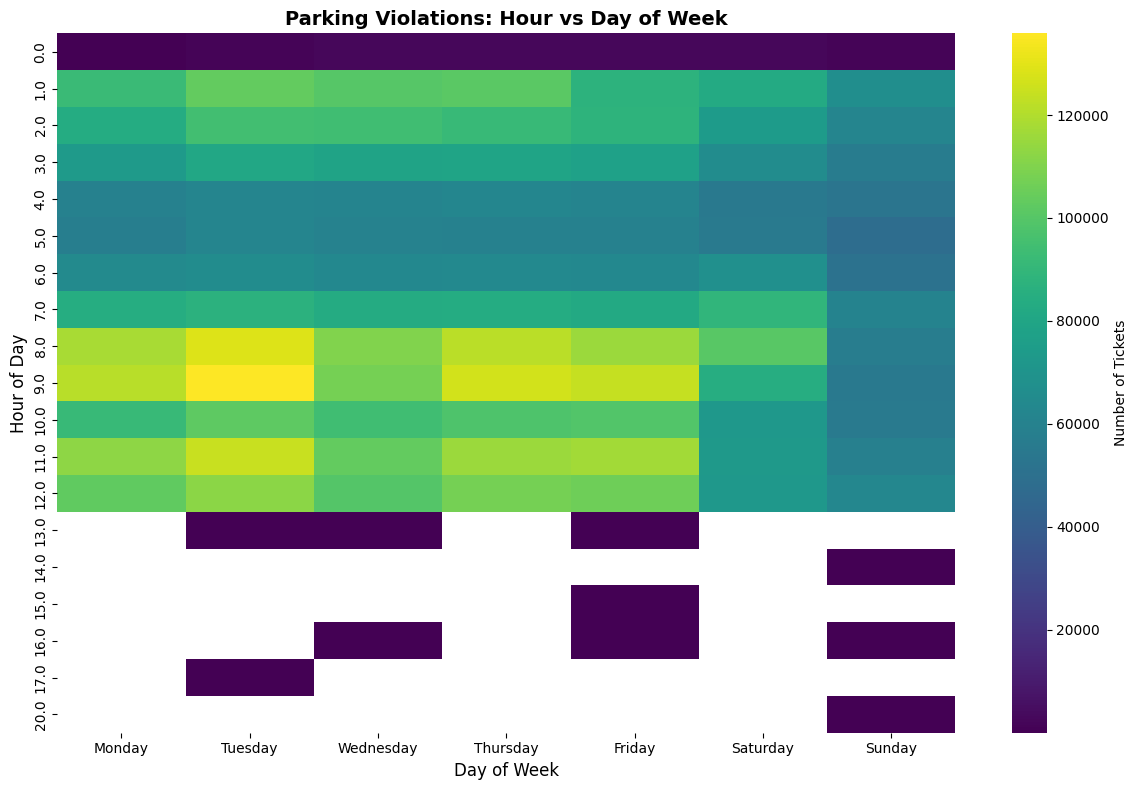

In [60]:
print("⏰ Time of Day Heatmap:")

# Extract hour and day of week
df_clean['hour'] = df_clean['violation_time'].astype(str).str[:2]
df_clean['hour'] = pd.to_numeric(df_clean['hour'], errors='coerce')
df_clean['day_of_week'] = df_clean['issue_date'].dt.day_name()

# Filter valid hours
hour_day_data = df_clean.dropna(subset=['hour', 'day_of_week'])
hour_day_data = hour_day_data[hour_day_data['hour'].between(0, 23)]

# Create pivot table
heatmap_data = hour_day_data.groupby(['hour', 'day_of_week']).size().unstack()

# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='viridis', annot=False, cbar_kws={'label': 'Number of Tickets'})
plt.title('Parking Violations: Hour vs Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Hour of Day', fontsize=12)
plt.tight_layout()
plt.show()

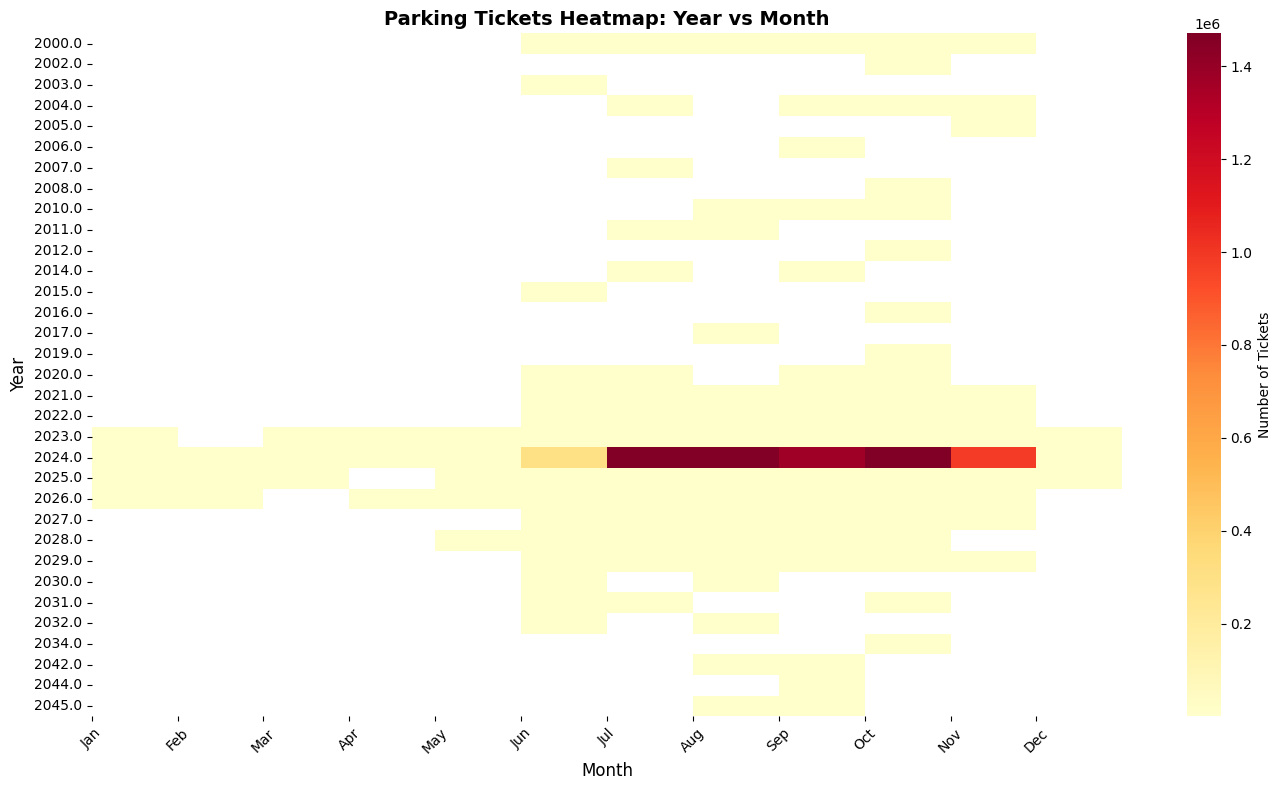

In [61]:
# Create year and month columns
df_clean['year'] = df_clean['issue_date'].dt.year
df_clean['month'] = df_clean['issue_date'].dt.month

# Create pivot table
ticket_heatmap = df_clean.groupby(['year', 'month']).size().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(ticket_heatmap, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Number of Tickets'})
plt.title('Parking Tickets Heatmap: Year vs Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)

# Rename months
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(12), month_names, rotation=45)

plt.tight_layout()
plt.show()

⏰ Analysis of Parking Restriction Hours


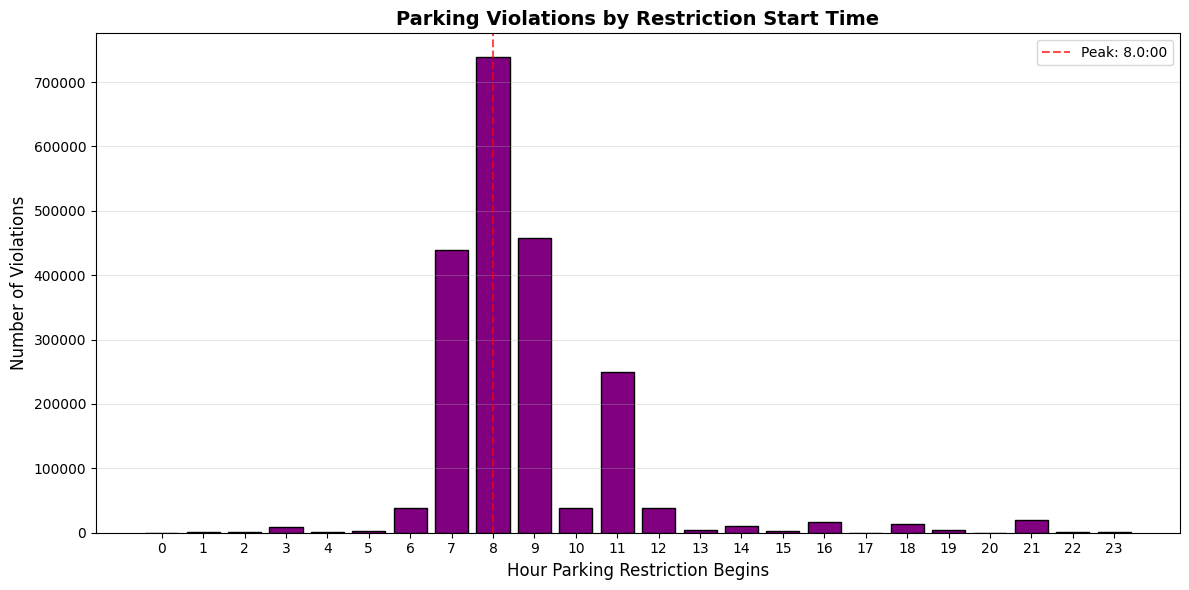


📊 Peak restriction hour: 8.0:00 (738,752 violations)


In [62]:
print("⏰ Analysis of Parking Restriction Hours")

# Clean and extract hours from from_hours_in_effect
if 'from_hours_in_effect' in df_clean.columns and df_clean['from_hours_in_effect'].notna().sum() > 10000:
    # Extract hour from time strings like "0730A", "0400P", "ALL"
    def extract_hour(time_str):
        if pd.isna(time_str) or time_str == 'ALL':
            return None
        time_str = str(time_str)
        # Extract digits
        import re
        match = re.search(r'(\d{1,2})', time_str)
        if match:
            hour = int(match.group(1))
            # Convert to 24-hour format if PM
            if 'P' in time_str and hour < 12:
                hour += 12
            return hour
        return None
    
    df_clean['restriction_start_hour'] = df_clean['from_hours_in_effect'].apply(extract_hour)
    valid_hours = df_clean['restriction_start_hour'].dropna()
    valid_hours = valid_hours[valid_hours.between(0, 23)]
    
    if len(valid_hours) > 0:
        hour_counts = valid_hours.value_counts().sort_index()
        
        plt.figure(figsize=(12, 6))
        plt.bar(hour_counts.index, hour_counts.values, color='purple', edgecolor='black')
        plt.xlabel('Hour Parking Restriction Begins', fontsize=12)
        plt.ylabel('Number of Violations', fontsize=12)
        plt.title('Parking Violations by Restriction Start Time', fontsize=14, fontweight='bold')
        plt.xticks(range(0, 24))
        plt.grid(axis='y', alpha=0.3)
        
        # Highlight peak hour
        peak_hour = hour_counts.idxmax()
        plt.axvline(x=peak_hour, color='red', linestyle='--', alpha=0.7, label=f'Peak: {peak_hour}:00')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📊 Peak restriction hour: {peak_hour}:00 ({hour_counts.max():,} violations)")
    else:
        print("ℹ️ Could not parse hour data from from_hours_in_effect")
else:
    print("ℹ️ from_hours_in_effect column has limited data")

In [63]:
# Check all column names in your dataframe
print("All available columns:")
for i, col in enumerate(df_clean.columns):
    print(f"  {i+1}. {col}")

# Look for any columns related to fines or amounts
print("\n🔍 Columns that might contain fine information:")
fine_related = [col for col in df_clean.columns if 'fine' in col.lower() or 'amount' in col.lower() or 'penalty' in col.lower()]
if fine_related:
    for col in fine_related:
        print(f"  - {col}")
else:
    print("  No fine-related columns found with 'fine', 'amount', or 'penalty' in the name")

# Also check the raw dataframe before cleaning
print("\n🔍 Raw dataframe columns (first 20):")
for i, col in enumerate(df.columns[:20]):
    print(f"  {i+1}. {col}")

All available columns:
  1. summons_number
  2. plate_id
  3. registration_state
  4. plate_type
  5. issue_date
  6. violation_code
  7. vehicle_body_type
  8. vehicle_make
  9. issuing_agency
  10. street_code1
  11. street_code2
  12. street_code3
  13. vehicle_expiration_date
  14. violation_location
  15. violation_precinct
  16. issuer_precinct
  17. issuer_code
  18. issuer_command
  19. issuer_squad
  20. violation_time
  21. time_first_observed
  22. violation_county
  23. violation_in_front_of_or_opposite
  24. house_number
  25. street_name
  26. intersecting_street
  27. date_first_observed
  28. law_section
  29. sub_division
  30. violation_legal_code
  31. days_parking_in_effect
  32. from_hours_in_effect
  33. to_hours_in_effect
  34. vehicle_color
  35. unregistered_vehicle?
  36. vehicle_year
  37. meter_number
  38. feet_from_curb
  39. violation_post_code
  40. violation_description
  41. no_standing_or_stopping_violation
  42. hydrant_violation
  43. double_parking

🌸 Seasonal Analysis:


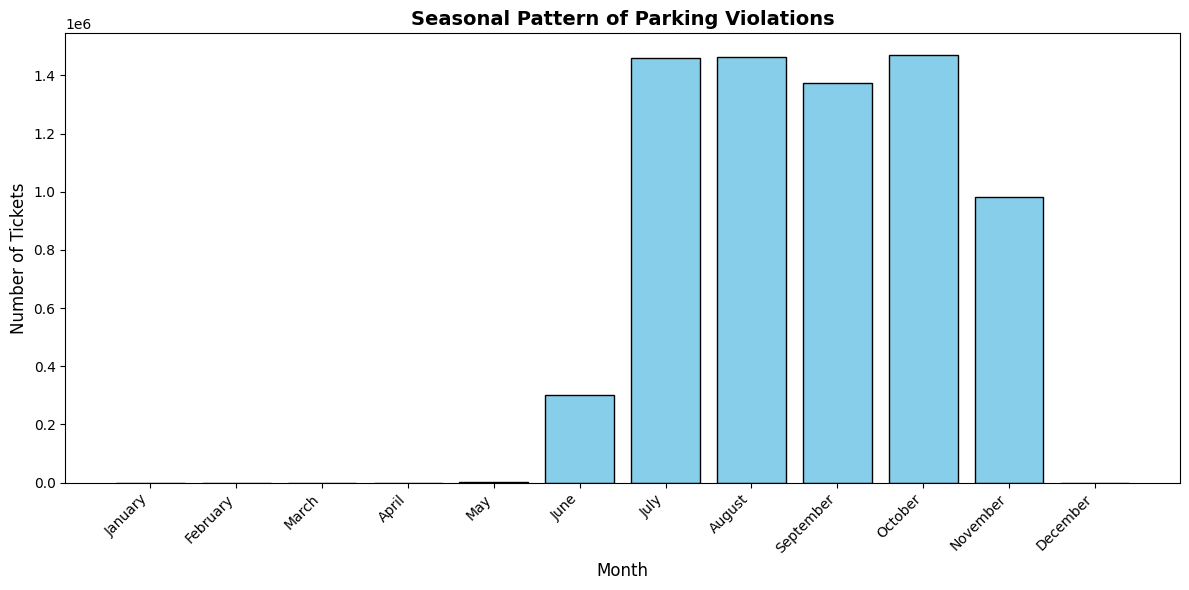

Busiest month: October (1,471,135 tickets)
Quietest month: December (21 tickets)


In [64]:
print("🌸 Seasonal Analysis:")

# Extract month name
df_clean['month_name'] = df_clean['issue_date'].dt.month_name()

# Order months correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_seasonal = df_clean['month_name'].value_counts()
monthly_seasonal = monthly_seasonal.reindex(month_order)

plt.figure(figsize=(12, 6))
plt.bar(monthly_seasonal.index, monthly_seasonal.values, color='skyblue', edgecolor='black')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Tickets', fontsize=12)
plt.title('Seasonal Pattern of Parking Violations', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find busiest and quietest months
print(f"Busiest month: {monthly_seasonal.idxmax()} ({monthly_seasonal.max():,} tickets)")
print(f"Quietest month: {monthly_seasonal.idxmin()} ({monthly_seasonal.min():,} tickets)")

🗺️ Vehicle Registration State Analysis:


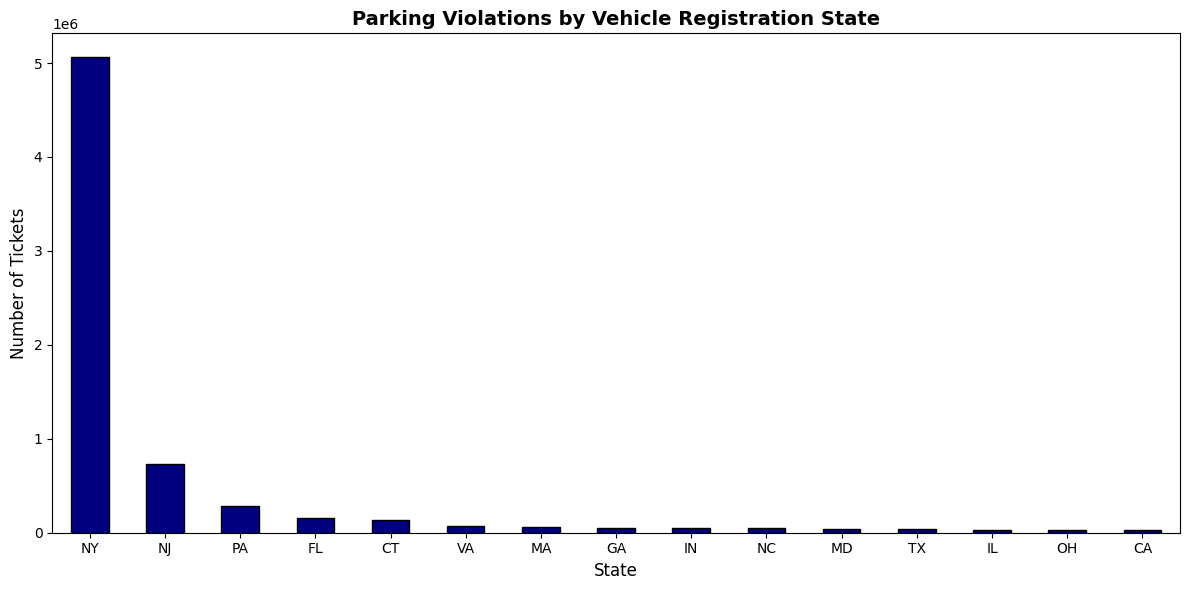

NY registered vehicles: 5,062,664 tickets (71.7%)
Out-of-state vehicles: 1,994,851 tickets (28.3%)


In [65]:
print("🗺️ Vehicle Registration State Analysis:")

if 'registration_state' in df_clean.columns:
    state_counts = df_clean['registration_state'].value_counts().head(15)
    
    plt.figure(figsize=(12, 6))
    state_counts.plot(kind='bar', color='navy', edgecolor='black')
    plt.xlabel('State', fontsize=12)
    plt.ylabel('Number of Tickets', fontsize=12)
    plt.title('Parking Violations by Vehicle Registration State', fontsize=14, fontweight='bold')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    ny_count = state_counts.get('NY', 0)
    non_ny_count = len(df_clean) - ny_count
    print(f"NY registered vehicles: {ny_count:,} tickets ({ny_count/len(df_clean)*100:.1f}%)")
    print(f"Out-of-state vehicles: {non_ny_count:,} tickets ({non_ny_count/len(df_clean)*100:.1f}%)")

In [68]:
print("=" * 60)
print("📊 FINAL SUMMARY - NYC PARKING VIOLATIONS")
print("=" * 60)

# Recalculate top violations if needed
if 'top_violations' not in locals():
    top_violations = df_clean.groupby(['violation_code', 'violation_description']).size().reset_index(name='ticket_count')
    top_violations = top_violations.sort_values('ticket_count', ascending=False).head(1)

summary = {
    "Total Tickets": f"{len(df_clean):,}",
    "Date Range": f"{df_clean['issue_date'].min().date()} to {df_clean['issue_date'].max().date()}",
    "Unique Vehicles (Plates)": f"{df_clean['plate_id'].nunique():,}",
    "Unique Makes": df_clean['vehicle_make'].nunique(),
    "Unique Colors": df_clean['vehicle_color_standard'].nunique() if 'vehicle_color_standard' in df_clean.columns else df_clean['vehicle_color'].nunique(),
    "Unique Violations": df_clean['violation_code'].nunique(),
    "Unique Precincts": df_clean['violation_precinct'].nunique(),
    "Top Violation": top_violations.iloc[0]['violation_description'] if len(top_violations) > 0 else "N/A",
    "Top Vehicle Make": df_clean['vehicle_make'].value_counts().index[0] if 'vehicle_make' in df_clean.columns else "N/A"
}

for key, value in summary.items():
    print(f"{key:25}: {value}")

print("\n" + "=" * 60)
print("✅ Analysis complete! Your data is ready for merging with a second dataset.")
print("=" * 60)

📊 FINAL SUMMARY - NYC PARKING VIOLATIONS
Total Tickets            : 7,056,795
Date Range               : 2000-06-03 to 2026-05-23
Unique Vehicles (Plates) : 2,488,960
Unique Makes             : 2287
Unique Colors            : 715
Unique Violations        : 98
Unique Precincts         : 160
Top Violation            : PHTO SCHOOL ZN SPEED VIOLATION
Top Vehicle Make         : TOYOT

✅ Analysis complete! Your data is ready for merging with a second dataset.


In [ ]:
# Save cleaned data for future use
df_clean.to_csv('parking_violations_cleaned.csv', index=False)
print("✅ Cleaned data saved to 'parking_violations_cleaned.csv'")

# Save a smaller sample for quick testing (10,000 rows)
df_clean.head(10000).to_csv('parking_violations_sample.csv', index=False)
print("✅ Sample data (10,000 rows) saved to 'parking_violations_sample.csv'")

print(f"\n📁 Final cleaned dataset shape: {df_clean.shape}")
print(f"📅 Date range: {df_clean['issue_date'].min()} to {df_clean['issue_date'].max()}")

✅ Cleaned data saved to 'parking_violations_cleaned.csv'
✅ Sample data (10,000 rows) saved to 'parking_violations_sample.csv'

📁 Final cleaned dataset shape: (7057515, 46)
📅 Date range: 2000-06-03 00:00:00 to 2045-09-04 00:00:00


In [71]:
print("=" * 60)
print("LOADING AND CLEANING FINES DATA")
print("=" * 60)

# Load your fines CSV
df_fines = pd.read_csv("fines_extracted_fixed.csv")  # Use your actual filename

# Rename columns if needed
df_fines.columns = ['violation_code', 'violation_description', 'fine_amount']

print(f"📊 Raw fines data: {len(df_fines)} rows")
print(f"📋 Columns: {df_fines.columns.tolist()}")

# Check unique values in fine_amount column
print(f"\n🔍 Unique values in Fine Amount column:")
print(df_fines['fine_amount'].value_counts().head(20))

# Clean the fine amount column
def clean_fine_amount(value):
    """Convert fine amount to float, handling non-numeric values"""
    if pd.isna(value):
        return np.nan
    
    value_str = str(value).strip()
    
    # Handle special cases
    if value_str.lower() == 'vary':
        return np.nan  # or use a default like 100? We'll use NaN for now
    if value_str == '$0' or value_str == '0':
        return 0.0
    
    # Remove $ sign and any spaces
    cleaned = value_str.replace('$', '').replace(',', '').strip()
    
    # Try to convert to float
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

# Apply the cleaning function
df_fines['fine_amount_clean'] = df_fines['fine_amount'].apply(clean_fine_amount)

# Remove rows where fine amount is NaN (including 'vary')
df_fines_clean = df_fines.dropna(subset=['fine_amount_clean'])

print(f"\n✅ After cleaning:")
print(f"   Total rows: {len(df_fines)}")
print(f"   Rows with valid fine amounts: {len(df_fines_clean)}")
print(f"   Removed {len(df_fines) - len(df_fines_clean)} rows with 'vary' or invalid values")

print(f"\n📊 Fine amount statistics:")
print(df_fines_clean['fine_amount_clean'].describe())

# Preview the cleaned data
print(f"\n📋 Preview of cleaned fines data:")
print(df_fines_clean[['violation_code', 'violation_description', 'fine_amount_clean']].head(10))

LOADING AND CLEANING FINES DATA
📊 Raw fines data: 91 rows
📋 Columns: ['violation_code', 'violation_description', 'fine_amount']

🔍 Unique values in Fine Amount column:
fine_amount
$115     26
$65      14
$45      11
$95      10
$35       7
$50       6
$515      5
$0        4
$60       3
$250      1
$180      1
$650      1
$165      1
vary      1
Name: count, dtype: int64

✅ After cleaning:
   Total rows: 91
   Rows with valid fine amounts: 90
   Removed 1 rows with 'vary' or invalid values

📊 Fine amount statistics:
count     90.000000
mean     109.888889
std      122.421674
min        0.000000
25%       50.000000
50%       80.000000
75%      115.000000
max      650.000000
Name: fine_amount_clean, dtype: float64

📋 Preview of cleaned fines data:
   violation_code           violation_description  fine_amount_clean
0               1   FAILURE TO DISPLAY BUS PERMIT              515.0
1               2  NO OPERATOR NAM/ADD/PH DISPLAY              515.0
2               3  UNAUTHORIZED PASSE